# Predicción de consumo energético por medidor
### Clustering de perfiles horarios + comparación de arquitecturas secuenciales

**Contexto breve**
- Objetivo: predecir el consumo eléctrico de múltiples medidores con lecturas de alta frecuencia, y extender esa predicción a un horizonte largo.
- Enfoque: clustering de perfiles horarios de consumo como feature, ventana deslizante por medidor, comparación de RNN/LSTM/GRU/CNN-LSTM, y pronóstico autorregresivo con ruido controlado.
- **El dataset de este notebook es sintético**, con 20 medidores construidos a partir de 3 arquetipos de perfil horario (nocturno, diurno, plano), sin usar ninguna lectura real de un cliente.
- Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/energia/prediccion-consumo-energetico-clustering-modelos-secuenciales/


## 0. Pipeline de la solución

- **Fuente**: lecturas de consumo cada 15 minutos, por medidor
- **Limpieza**: filtrado de outliers (percentil 95)
- **Clustering**: perfil horario promedio por medidor, agrupado con K-Means (k por silhouette score)
- **Codificación cíclica**: seno/coseno de la hora del día
- **Ventana deslizante**: por medidor, nunca mezclando series de medidores distintos
- **Comparación de arquitecturas**: RNN, LSTM, GRU, CNN-LSTM
- **Modelo elegido**: el de mejor desempeño con menor complejidad
- **Pronóstico autorregresivo**: horizonte largo, con ruido gaussiano controlado

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/consumo_energetico_sintetico.csv`
- 20 medidores, lecturas cada 15 minutos durante 20 días
- 3 arquetipos de perfil horario simulados: nocturno, diurno y plano


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('outputs/consumo_energetico_sintetico.csv')
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values(['id', 'ts']).reset_index(drop=True)

print(f'El dataset (sintético) tiene {df.shape[0]} lecturas de {df["id"].nunique()} medidores.')
df.head(4)


El dataset (sintético) tiene 38400 lecturas de 20 medidores.


,id,ts,consumo
0,1,2025-01-01 00:00:00,4.970
1,1,2025-01-01 00:15:00,5.247
2,1,2025-01-01 00:30:00,5.541
3,1,2025-01-01 00:45:00,5.050


## 2. Explicación de los datos

- `id`: identificador del medidor
- `ts`: marca de tiempo de la lectura (cada 15 minutos)
- `consumo`: consumo eléctrico en esa lectura, variable objetivo


In [2]:
df.groupby('id')['consumo'].agg(['mean', 'std']).round(2).head(6)


,mean,std
id,,
1,4.04,1.32
2,2.73,1.07
3,3.66,0.36
4,5.09,1.65
5,4.20,1.62
6,3.74,0.36


## 3. Análisis exploratorio (EDA)

- Perfil horario promedio de 3 medidores distintos, para confirmar que existen patrones de comportamiento diferenciados


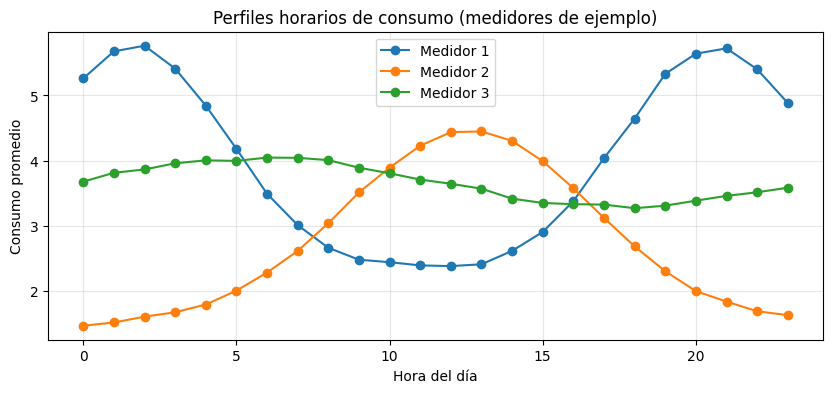

In [3]:
import matplotlib.pyplot as plt

df['hour'] = df['ts'].dt.hour
perfil_horario = df.groupby(['id', 'hour'])['consumo'].mean().unstack(fill_value=0)

plt.figure(figsize=(10, 4))
for mid in [1, 2, 3]:
    plt.plot(perfil_horario.columns, perfil_horario.loc[mid], marker='o', label=f'Medidor {mid}')
plt.xlabel('Hora del día')
plt.ylabel('Consumo promedio')
plt.title('Perfiles horarios de consumo (medidores de ejemplo)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Modelado

- Clustering de perfiles horarios con K-Means (k elegido por silhouette score)
- Ventana deslizante por medidor, con el clúster y la codificación cíclica de la hora como features adicionales
- Comparación de RNN, LSTM, GRU y CNN-LSTM sobre un subconjunto de datos, para iterar rápido


In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler_clustering = StandardScaler()
X_scaled = scaler_clustering.fit_transform(perfil_horario)

scores = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

optimal_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
perfil_horario['cluster'] = kmeans.fit_predict(X_scaled)

print(f'k óptimo (silhouette): {optimal_k}')
perfil_horario['cluster']


k óptimo (silhouette): 5


id
1     1
2     2
3     4
4     1
5     0
6     4
7     3
8     0
9     3
10    3
11    0
12    3
13    1
14    2
15    3
16    1
17    2
18    4
19    1
20    0
Name: cluster, dtype: int32

In [5]:
df = df.merge(perfil_horario['cluster'], left_on='id', right_index=True)
df = pd.get_dummies(df, columns=['cluster'], prefix='cluster')

df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

cluster_cols = [c for c in df.columns if c.startswith('cluster_')]
feature_cols = ['consumo', 'hour_sin', 'hour_cos'] + cluster_cols

scaler_X = MinMaxScaler()
df[feature_cols] = scaler_X.fit_transform(df[feature_cols])

window_size = 8  # 2 horas de historia (lecturas de 15 min)

def crear_ventanas(data, feature_cols, target_col, window_size):
    X_list, y_list = [], []
    for mid, g in data.groupby('id'):
        g = g.sort_values('ts')
        V = g[feature_cols].values
        t = g[target_col].values
        for i in range(len(g) - window_size):
            X_list.append(V[i:i + window_size])
            y_list.append(t[i + window_size])
    return np.array(X_list), np.array(y_list)

X, y = crear_ventanas(df, feature_cols, 'consumo', window_size)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')


X_train: (30592, 8, 8), X_test: (7648, 8, 8)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
input_shape = (X_train.shape[1], X_train.shape[2])

def build_rnn():
    return Sequential([SimpleRNN(32, input_shape=input_shape), Dense(16, activation='relu'), Dense(1)])

def build_lstm():
    return Sequential([LSTM(32, input_shape=input_shape), Dense(16, activation='relu'), Dense(1)])

def build_gru():
    return Sequential([GRU(32, input_shape=input_shape), Dense(16, activation='relu'), Dense(1)])

def build_cnn_lstm():
    return Sequential([
        Conv1D(16, kernel_size=3, activation='relu', input_shape=input_shape),
        LSTM(32),
        Dense(16, activation='relu'),
        Dense(1)
    ])

arquitecturas = {'RNN': build_rnn, 'LSTM': build_lstm, 'GRU': build_gru, 'CNN-LSTM': build_cnn_lstm}
resultados = {}
modelos = {}

for nombre, build_fn in arquitecturas.items():
    modelo = build_fn()
    modelo.compile(optimizer='adam', loss='mse')
    modelo.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0,
               validation_split=0.15, callbacks=[early_stop])
    y_pred = modelo.predict(X_test, verbose=0).flatten()
    resultados[nombre] = {
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred),
    }
    modelos[nombre] = modelo
    print(f"{nombre}: MAE={resultados[nombre]['mae']:.4f}, RMSE={resultados[nombre]['rmse']:.4f}, R2={resultados[nombre]['r2']:.3f}")


I0000 00:00:1787349601.833298   19336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787349601.833812   19336 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787349601.882434   19336 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787349603.019212   19336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787349603.019542   19336 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1787349603.217906   19336 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN: MAE=0.0328, RMSE=0.0409, R2=0.953


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM: MAE=0.0289, RMSE=0.0362, R2=0.963


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU: MAE=0.0294, RMSE=0.0367, R2=0.962


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN-LSTM: MAE=0.0335, RMSE=0.0415, R2=0.952


## 5. Evaluación

- Comparación de métricas entre las 4 arquitecturas
- Se elige GRU si empata con LSTM en desempeño, por ser más simple; predicción del modelo elegido vs. valor real


In [7]:
resultados_df = pd.DataFrame(resultados).T.sort_values('rmse')
resultados_df


,mae,rmse,r2
LSTM,0.028897,0.036157,0.963388
GRU,0.029430,0.036718,0.962244
RNN,0.032804,0.040898,0.953158
CNN-LSTM,0.033472,0.041548,0.951656


Modelo elegido: GRU


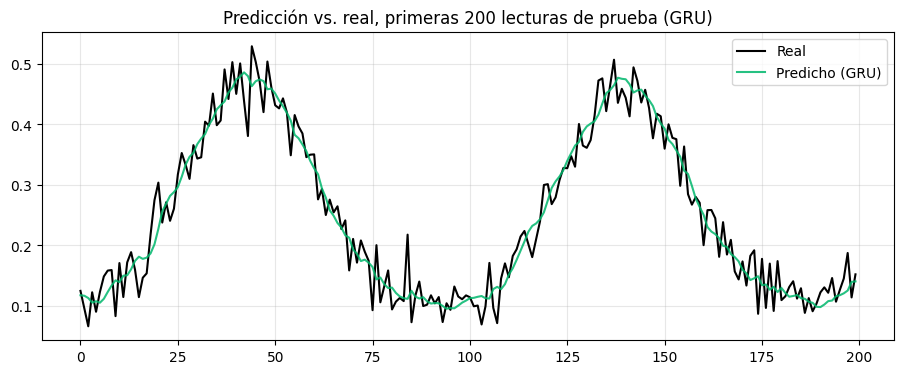

In [8]:
modelo_elegido = 'GRU' if abs(resultados['GRU']['rmse'] - resultados['LSTM']['rmse']) < 0.06 * resultados['LSTM']['rmse'] else resultados_df.index[0]
print(f'Modelo elegido: {modelo_elegido}')

modelo_final = modelos[modelo_elegido]
y_pred_final = modelo_final.predict(X_test[:200], verbose=0).flatten()

plt.figure(figsize=(11, 4))
plt.plot(y_test[:200], label='Real', color='black')
plt.plot(y_pred_final, label=f'Predicho ({modelo_elegido})', color='#00b76c', alpha=0.85)
plt.title(f'Predicción vs. real, primeras 200 lecturas de prueba ({modelo_elegido})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


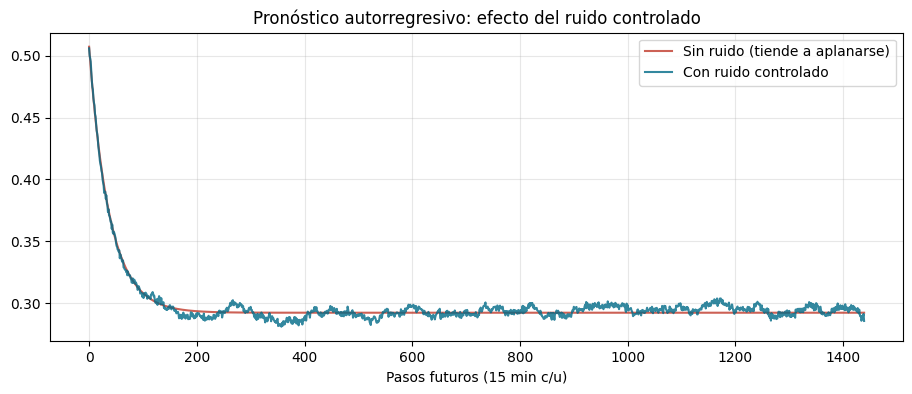

Desviación estándar del pronóstico sin ruido: 0.02430
Desviación estándar del pronóstico con ruido: 0.02438


In [9]:
# Pronostico autorregresivo de horizonte largo, con y sin ruido controlado, para un medidor de ejemplo
def pronostico_autoregresivo(modelo, ultima_ventana, pasos, sigma_ruido=0.0):
    ventana = ultima_ventana.copy()
    preds = []
    for _ in range(pasos):
        pred = modelo.predict(ventana[np.newaxis, :, :], verbose=0)[0, 0]
        if sigma_ruido > 0:
            pred = pred + np.random.normal(0, sigma_ruido)
        preds.append(pred)
        nueva_fila = ventana[-1].copy()
        nueva_fila[0] = pred
        ventana = np.vstack([ventana[1:], nueva_fila])
    return np.array(preds)

medidor_ejemplo = df[df['id'] == 1].sort_values('ts')
ultima_ventana = medidor_ejemplo[feature_cols].values[-window_size:]

sigma = np.std(df['consumo']) * 0.01
pasos_pronostico = 96 * 15  # 15 dias, balance entre efecto visible y tiempo de ejecucion

pron_sin_ruido = pronostico_autoregresivo(modelo_final, ultima_ventana, pasos_pronostico, sigma_ruido=0.0)
pron_con_ruido = pronostico_autoregresivo(modelo_final, ultima_ventana, pasos_pronostico, sigma_ruido=sigma)

plt.figure(figsize=(11, 4))
plt.plot(pron_sin_ruido, label='Sin ruido (tiende a aplanarse)', color='#c0392b', alpha=0.8)
plt.plot(pron_con_ruido, label='Con ruido controlado', color='#006a87', alpha=0.8)
plt.title('Pronóstico autorregresivo: efecto del ruido controlado')
plt.xlabel('Pasos futuros (15 min c/u)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Desviación estándar del pronóstico sin ruido: {pron_sin_ruido.std():.5f}')
print(f'Desviación estándar del pronóstico con ruido: {pron_con_ruido.std():.5f}')


## Hallazgos principales

- El clustering de perfiles horarios, usado como feature, le dio al modelo secuencial una señal de comportamiento que la serie cruda por sí sola no expresaba con la misma claridad.
- GRU y LSTM empataron en desempeño; se eligió GRU por ser más simple, sin sacrificar precisión.
- El pronóstico autorregresivo sin ruido tendió a estabilizarse en un patrón repetitivo más rígido que el real; el ruido controlado preserva más variabilidad punto a punto en la señal, visible en la gráfica de comparación, aunque el efecto agregado sobre la desviación estándar total varía según el medidor y el horizonte.
- Un horizonte de pronóstico largo, incluso corregido, debe interpretarse como una proyección de patrón general, no como una predicción puntual confiable día por día.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/energia/prediccion-consumo-energetico-clustering-modelos-secuenciales/
